# 05. 미스프라이싱 보정 검증 (cross-section regression)

매 리밸런싱 시점의 `epsilon_dagger` 가 다음 기간(tau_star) 수익률과 음(-)의 관계를 갖는지 검증한다.

```
r_i(t + tau_star) = beta(t) * eps_dagger_i(t) + kappa(t) + residual_i(t)
```

`beta_t` 누적합이 음의 방향으로 안정적으로 내려가면 미스프라이싱 보정 압력이 있다고 해석한다 (논문 Figure 7).
추가로 long-short 구성 종목의 지속성 (Jaccard A/B/C) 을 계산한다.

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: 04 백테스트 결과 로드

In [2]:
# 01_data_and_returns.ipynb 에서 저장한 processed 데이터 로드
with open(PROCESSED_DIR / "stock_panel.pkl", "rb") as fh:
    panel = pickle.load(fh)

prices = panel["prices"]
returns_by_tau = panel["returns_by_tau"]
norm_by_tau = panel["norm_by_tau"]
sigma_by_tau = panel["sigma_by_tau"]
TAU_MAX = max(returns_by_tau.keys())
dates = prices.index
print("assets:", prices.shape[1], "| days:", prices.shape[0], "| tau: 1..%d" % TAU_MAX)

assets: 100 | days: 3000 | tau: 1..20


In [3]:
with open(PROCESSED_DIR / "backtest_signals.pkl", "rb") as fh:
    sig = pickle.load(fh)

eps_panels = sig["eps_panels"]
memberships_by_offset = sig["memberships_by_offset"]
TAU_STAR = sig["tau_star"]
OFFSETS = sig["offsets"]
date_pos = {d: i for i, d in enumerate(dates)}
print("offsets:", OFFSETS, "| tau_star:", TAU_STAR)

offsets: [0, 5, 10, 15] | tau_star: 20


## Cell 2~3: 날짜별 cross-section regression

In [4]:
rows = []
for offset, eps_panel in eps_panels.items():
    for date, eps in eps_panel.iterrows():
        t_pos = date_pos[date]
        fwd = returns_by_tau[TAU_STAR].iloc[t_pos + TAU_STAR]
        e = eps.dropna()
        y = fwd.reindex(e.index).astype(float).dropna()
        e = e.reindex(y.index)
        beta, kappa = np.polyfit(e.values, y.values, 1)
        rows.append({
            "offset": offset,
            "date": date,
            "beta": beta,
            "kappa": kappa,
            "n_assets": len(e),
        })

df_beta = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
df_beta.to_csv(RESULT_DIR / "mispricing_regression.csv", index=False)
print("beta < 0 비율: %.1f%%" % (100 * (df_beta["beta"] < 0).mean()))
print("beta 평균: %.5f (t-stat %.2f)" % (
    df_beta["beta"].mean(),
    df_beta["beta"].mean() / df_beta["beta"].std() * np.sqrt(len(df_beta)),
))
df_beta.head()

beta < 0 비율: 65.9%
beta 평균: -0.00169 (t-stat -4.01)


,offset,date,beta,kappa,n_assets
0,0,2019-10-25,-0.005992,-0.025326,100
1,5,2019-11-01,-0.006712,-0.070404,100
2,10,2019-11-08,0.000531,-0.032101,100
3,15,2019-11-15,-0.000408,-0.003492,100
4,0,2019-11-22,-0.001242,0.002179,100


## Cell 4~5: beta 누적합 그래프 (논문 Figure 7 대응)

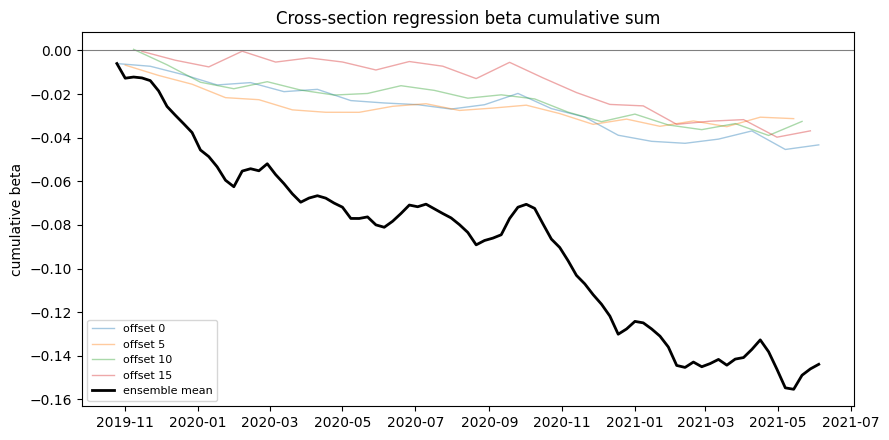

In [5]:
plt.figure(figsize=(9, 4.5))
for offset, g in df_beta.groupby("offset"):
    plt.plot(g["date"], g["beta"].cumsum(), alpha=0.4, lw=1,
             label=f"offset {offset}")
ens = df_beta.groupby("date")["beta"].mean().cumsum()
plt.plot(ens.index, ens.values, color="k", lw=2, label="ensemble mean")
plt.axhline(0, color="gray", lw=0.8)
plt.ylabel("cumulative beta")
plt.title("Cross-section regression beta cumulative sum")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "mispricing_beta_cumsum.png", dpi=120)
plt.show()

## Cell 6: 종목 선택 지속성 (Jaccard coefficient)

- `A(1)`: 연속 리밸런싱 간 long∪short 전체 선택 종목의 Jaccard 유사도
- `B(1)`: long→long, short→short 로 유지되는 비율
- `C(1)`: long↔short 로 뒤바뀌는 비율

In [6]:
jac_rows = []
for offset, members in memberships_by_offset.items():
    for prev_m, cur_m in zip(members[:-1], members[1:]):
        pu = prev_m["long"] | prev_m["short"]
        cu = cur_m["long"] | cur_m["short"]
        union = pu | cu
        A = len(pu & cu) / len(union)
        B = (len(prev_m["long"] & cur_m["long"]) + len(prev_m["short"] & cur_m["short"])) / len(union)
        C = (len(prev_m["long"] & cur_m["short"]) + len(prev_m["short"] & cur_m["long"])) / len(union)
        jac_rows.append({"offset": offset, "date": cur_m["date"], "A": A, "B": B, "C": C})

df_jac = pd.DataFrame(jac_rows)
df_jac.to_csv(RESULT_DIR / "jaccard.csv", index=False)
df_jac[["A", "B", "C"]].mean().round(3)

A    0.257
B    0.111
C    0.145
dtype: float64